## Dataset Overview

This dataset was obtained from Kaggle. It contains information about various factors that may influence student academic performance, such as study habits, sleep, and demographic characteristics.

The dataset has 6607 rows and 20 columns.

My guiding research question is: "What factors are most strongly associated with student exam performance?"

Through this analysis, I aim to explore relationships between lifestyle, demographic variables, and academic outcomes.

## Section 1

In [38]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

df.shape

(6607, 20)

In [39]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

The dataset includes both numerical and categorical variables, which is important for this analysis. Numerical variables such as study hours, sleep hours, and exam scores will allow me to measure trends and relationships, while categorical variables like gender or access to resources will help compare different groups of students.

At first glance, the data types seem appropriate. However deepe analysis will reveal any inconsistencies, such as numbers stored as text, as that could affect calculations later on.

In [40]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Looking at the summary statistics, the first thing that stands out is the variation in exam scores. The wide range suggests that students in the dataset perform very differently from each other, which makes it worth investigating what might be driving those differences.

For variables like hours studied, I would expect the distribution to be somewhat uneven. Not all students follow the same habits, so it’s likely that a smaller group studies much more than the average. If that is the case, the mean would be pulled upward compared to the median, indicating a right-skewed distribution.

Based on the summary statistics, some variables appear to have a relatively wide range between their minimum and maximum values. For example, Hours_Studied and Sleep_Hours likely vary significantly across students, which suggests that there may be extreme values in the dataset. Even though I have not visualized them yet, these large ranges indicate that some observations could be far from the average. In this context, that is not necessarily a problem, since it is realistic that some students study much more or sleep much less than others.

In [41]:
df["Parental_Involvement"].value_counts()

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

In [42]:
df["Access_to_Resources"].value_counts()

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

In [43]:
df["Extracurricular_Activities"].value_counts()

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

In [44]:
df["Motivation_Level"].value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

In [45]:
df["Internet_Access"].value_counts()

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

In [46]:
df["Family_Income"].value_counts()

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

In [47]:
df["Teacher_Quality"].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [48]:
df["School_Type"].value_counts()

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

In [49]:
df["Peer_Influence"].value_counts()

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

In [50]:
df["Learning_Disabilities"].value_counts()

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

In [51]:
df["Parental_Education_Level"].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [52]:
df["Distance_from_Home"].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [53]:
df["Gender"].value_counts()

Gender
Male      3814
Female    2793
Name: count, dtype: int64

In [54]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Most of the dataset is complete, which makes the analysis more reliable since I don’t have to deal with widespread missing data. However, a few variables do contain missing values, specifically Teacher_Quality (78), Parental_Education_Level (90), and Distance_from_Home (67).

I decided not to drop these rows because that would remove a noticeable number of observations and could slightly distort the overall distribution of the dataset. Since the missing values are only in a few columns and not across the entire dataset, dropping them would be unnecessary.

Instead, I will fill the missing values using the mode for each column. This makes sense because these variables are categorical, and using the most common category keeps the data consistent with the general pattern of the dataset.

This approach isn’t perfect, since I’m essentially assuming that the missing values follow the same distribution as the rest of the data. But given the relatively small number of missing entries, it’s reasonable and it preserves the dataset without introducing major bias.

## Section 2

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

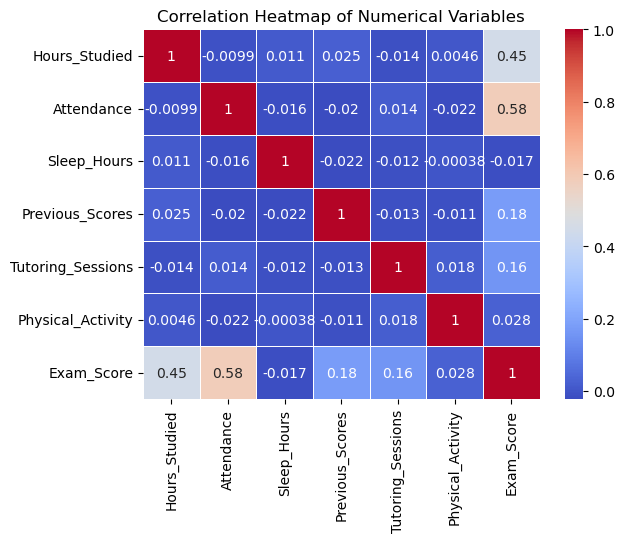

In [56]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm",linewidths=0.6, linecolor="white")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The strongest positive correlation with Exam_Score is Attendance (around 0.58), followed by Hours_Studied (around 0.45). Both of these relationships make sense since students who attend class more regularly and spend more time studying are likely to perform better academically.

On the other hand, Sleep_Hours shows a very weak negative correlation with Exam_Score (around -0.02), which suggests almost no relationship. This is somewhat surprising, since sleep is generally expected to impact performance, but it may indicate that sleep alone is not a strong predictor in this dataset.

Overall, the strongest relationships are tied to direct academic behaviors like attendance and study time, which makes sense, while lifestyle variables such as sleep and physical activity appear to have little measurable impact on exam performance in this case.

In [57]:
df.groupby("Parental_Involvement")["Exam_Score"].mean()

Parental_Involvement
High      68.092767
Low       66.358265
Medium    67.098156
Name: Exam_Score, dtype: float64

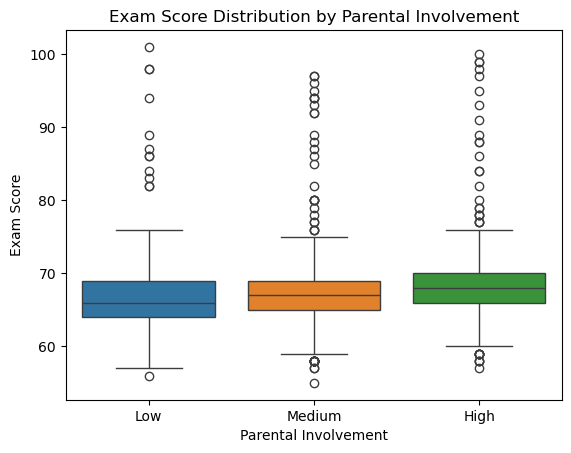

In [58]:
sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=df, hue="Parental_Involvement")

plt.title("Exam Score Distribution by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")
plt.show()

The boxplot shows a clear pattern between parental involvement and exam score.

Students with high parental involvement tend to have slightly higher median exam scores compared to those with medium and low involvement. The shift upward from low → medium → high suggests a consistent relationship.

Another noticeable detail is that the spread of scores is fairly similar across all three groups, which means that parental involvement does not completely determine performance. There are still students with low involvement who perform well and students with high involvement who perform closer to the average.

There are also several outliers in each category, particularly on the higher end of exam scores. This suggests that some students perform exceptionally well regardless of their level of parental involvement.

## Section 3

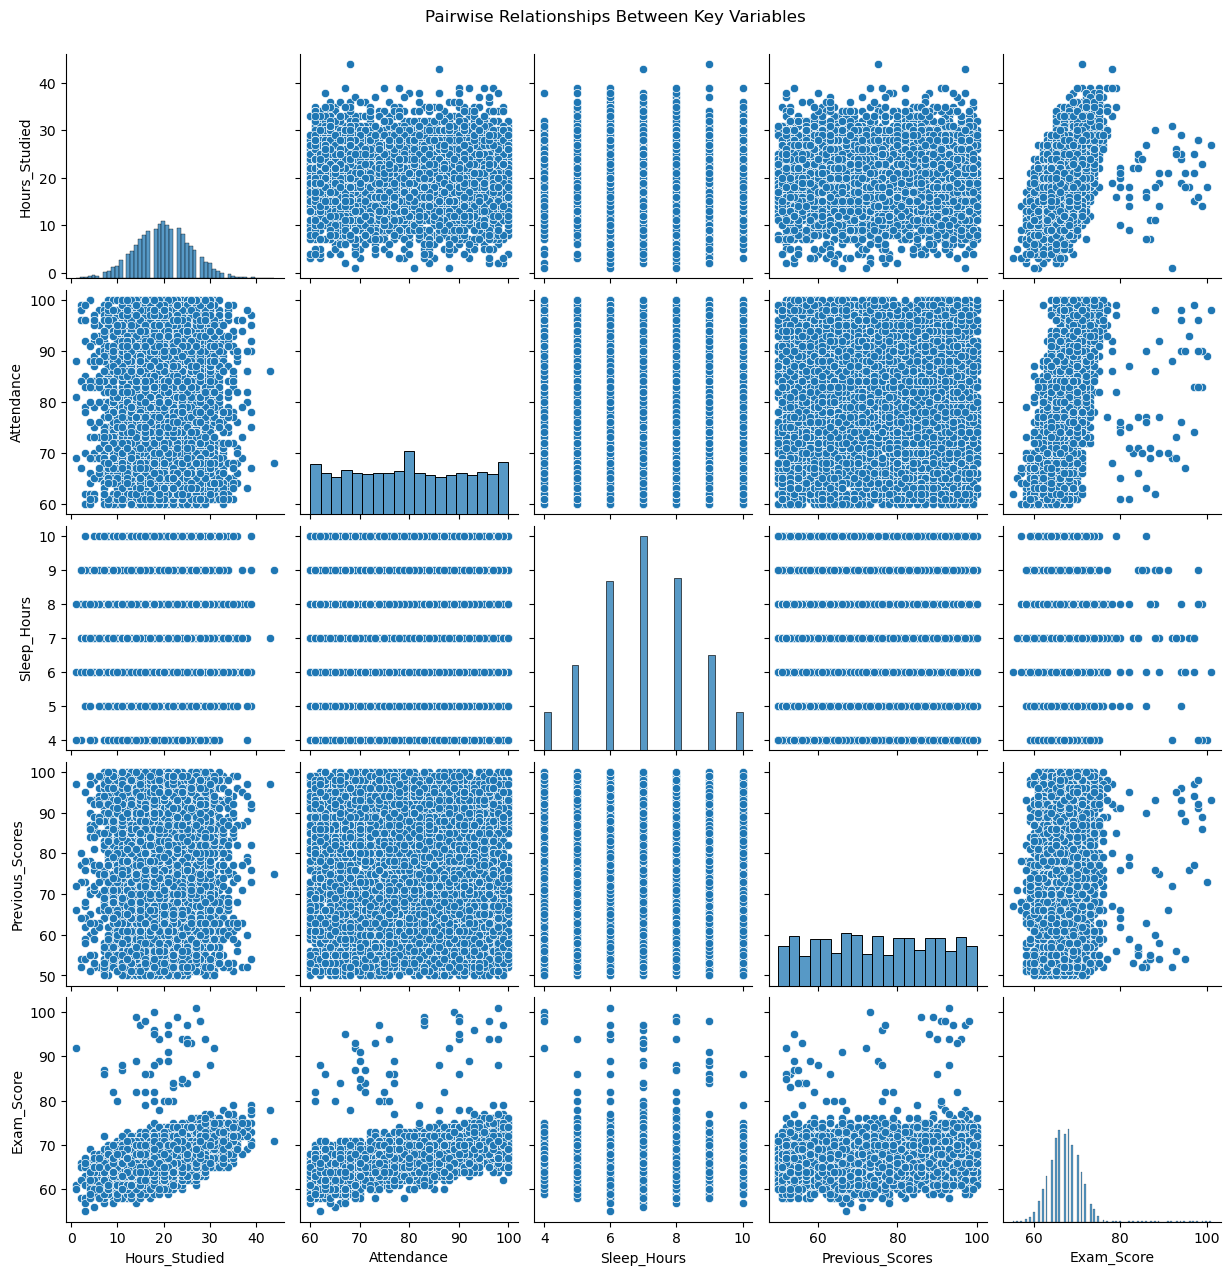

In [59]:
sns.pairplot(df[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Exam_Score"]])
plt.suptitle("Pairwise Relationships Between Key Variables", y=1.02)
plt.show()

The pair plot provides a more detailed view of how the numerical variables relate to each other.

The most noticeable pattern appears between Hours_Studied and Exam_Score, where there is a clear upward trend. This reinforces the idea that increased study time is associated with better performance. A similar pattern can be seen between Attendance and Exam_Score, which aligns with its relatively strong correlation.

In contrast, variables like Sleep_Hours show no clear relationship with exam scores. The horizontal bands in the plot indicate that sleep is measured in discrete values, and the lack of a visible trend suggests that it does not strongly influence performance on its own.

Previous_Scores show a weak positive relationship with Exam_Score, but the spread of points indicates that past performance alone is not a strong predictor in this dataset.

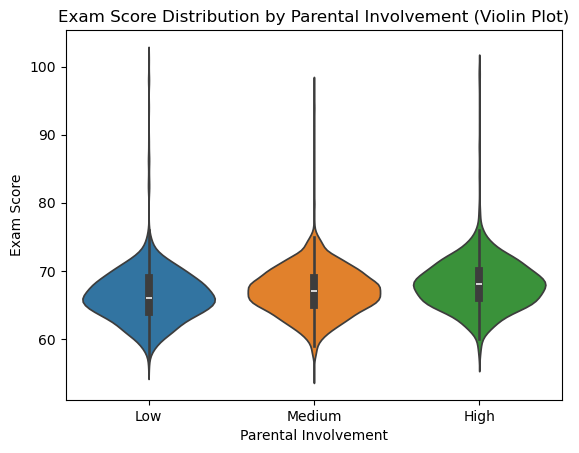

In [60]:
sns.violinplot(x="Parental_Involvement", y="Exam_Score", data=df, hue=df["Parental_Involvement"])

plt.title("Exam Score Distribution by Parental Involvement (Violin Plot)")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")
plt.show()

The violin plot gives a more detailed view of the distribution of exam scores across different levels of parental involvement.

While the overall pattern is similar to the boxplot, this visualization shows how the data is concentrated within each group. The distribution for high parental involvement appears slightly shifted upward, with more density at higher exam scores.

At the same time, all groups show a relatively wide spread, which reinforces the idea that parental involvement is not the only factor affecting performance.

This visualization highlights that even when averages are similar, the shape of the distribution can still differ between groups.

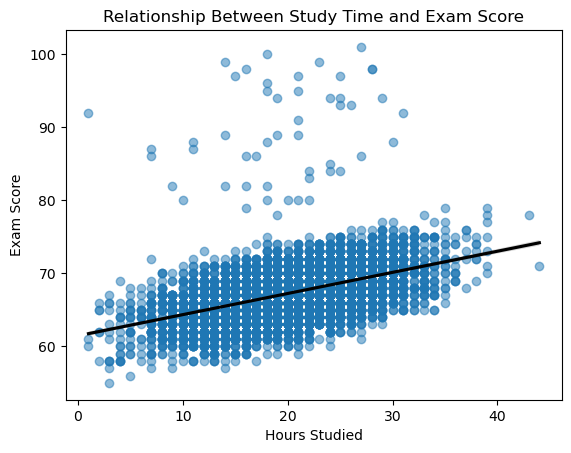

In [61]:
sns.regplot(x="Hours_Studied", y="Exam_Score", data=df, scatter_kws={"alpha": 0.5}, line_kws={"color": "black"})

plt.title("Relationship Between Study Time and Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

The regression plot shows a positive relationship between hours studied and exam score.

The upward trend of the fitted line indicates that students who study more tend to achieve higher scores. Unlike the correlation heatmap, this visualization makes the relationship easier to interpret visually.

There is still some variability around the line, which suggests that study time alone does not fully determine performance. However, it appears to be one of the strongest predictors in the dataset.

## Section 4

In [62]:
# Test 1: Two sample t-test
# Do students with internet access perform better?

from scipy import stats

group_yes = df[df["Internet_Access"] == "Yes"]["Exam_Score"]
group_no = df[df["Internet_Access"] == "No"]["Exam_Score"]

t_stat, p_value = stats.ttest_ind(group_yes, group_no)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 4.1890
p-value: 0.0000


To test whether internet access is associated with differences in exam performance, I conducted a two-sample t-test comparing the mean exam scores of students with and without internet access.

The null hypothesis (H₀) is that there is no difference in average exam scores between the two groups. The alternative hypothesis (H₁) is that there is a difference in mean exam scores between students with and without internet access.

A two-sample t-test is appropriate here because I am comparing the means of a numerical variable (Exam_Score) across two independent groups.

The test returned a t-statistic of 4.1890 and a p-value of 0.0000. At a significance level of α = 0.05, I reject the null hypothesis.

This means that there is a statistically significant difference in exam scores between students with and without internet access. This suggests that internet access is associated with better academic performance.

In [63]:
# Test 2: Pearson Correlation Test
# Is the relationship between Hours_Studied and Exam_Score statistically significant?

r, p_value = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])

print(f"Pearson r: {r:.4f}")
print(f"p-value: {p_value:.4f}")

Pearson r: 0.4455
p-value: 0.0000


To evaluate whether the relationship between hours studied and exam performance is statistically significant, I conducted a Pearson correlation test.

The null hypothesis (H₀) is that there is no linear relationship between hours studied and exam score (correlation = 0). The alternative hypothesis (H₁) is that there is a non-zero relationship between the two variables.

This test is appropriate because both variables are numerical, and I want to determine whether the observed relationship is statistically significant.

The test returned a correlation coefficient (r) of 0.4455 and a p-value of 0.0000. At a significance level of α = 0.05, I reject the null hypothesis. This indicates that the relationship between hours studied and exam score is statistically significant. This supports the earlier findings that students who study more tend to achieve higher exam scores.

## Section 5

### A. Summary of Major Findings

The main goal of this analysis was to understand which factors are most strongly associated with student exam performance.

The most consistent pattern across all sections was the importance of academic related variables. In particular, attendance and hours studied showed the strongest relationships with exam score. The correlation heatmap indicated that attendance had the highest correlation with exam performance, followed by hours studied, and this was reinforced visually in both the pair plot and regression plot.

Previous scores also showed a positive relationship with exam performance, although it was weaker than expected. This suggests that while past performance matters, it is not a dominant predictor on its own.

In contrast, variables such as sleep hours and physical activity showed very weak relationships with exam score. The pair plot confirmed this by showing little to no visible trend, indicating that these factors may not have a strong direct impact in this dataset.

The group comparison analysis further highlighted the role of support systems. Students with higher parental involvement tended to have slightly higher exam scores, although there was still significant variation within each group.

The hypothesis tests supported these observations. The t-test showed a statistically significant difference in exam scores between students with and without internet access, suggesting that access to resources may influence performance. The Pearson correlation test confirmed that the relationship between hours studied and exam score is statistically significant, reinforcing the patterns observed in earlier visualizations.


### B. Limitations and Caveats

One limitation of this dataset is that it does not provide information about how the data was collected, which makes it difficult to assess how representative it is of a broader student population. There may be underlying biases depending on the sample.

There were some missing values in a few columns, which were handled by filling them with the most frequent category. While this approach preserves the dataset, it introduces some assumptions about the distribution of those variables.

Another limitation is that most relationships in the dataset are moderate or weak. While some variables show statistically significant results, the overall patterns suggest that academic performance is influenced by multiple interacting factors rather than a single strong predictor.


### C. Next Steps

If I were to continue this analysis, I would focus on building a predictive model to estimate exam scores based on the available variables. A regression model could help quantify how much each factor contributes to performance.

I would also be interested in including additional variables that are not present in this dataset, such as study environment, mental health, or quality of instruction, as these could provide a more complete understanding of academic performance.

Also, it would be interesting to explore the interaction effects between variables. For example, it would be interesting to see whether the impact of study time differs depending on levels of parental involvement or access to resources.